# 04 - Feature Selection

This notebook demonstrates the feature selection pipeline:
1. Load preprocessed train/test data
2. Run Variance Threshold → Mutual Information → Binary PSO on training data ONLY
3. Transform test data using fitted selectors
4. Save selected features


In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
import config
from src.io import save_dataframe, save_table, logger
from src.feature_selection import run_feature_selection, transform_selected
from src.visualization import setup_style, plot_feature_importance
setup_style()

## Step 1: Load Preprocessed Data

In [2]:
X_train = pd.read_csv(config.PROCESSED_DIR / "X_train_preprocessed.csv")
X_test = pd.read_csv(config.PROCESSED_DIR / "X_test_preprocessed.csv")
y_train = pd.read_csv(config.PROCESSED_DIR / "y_train.csv").iloc[:, 0]
y_test = pd.read_csv(config.PROCESSED_DIR / "y_test.csv").iloc[:, 0]

print(f"Train shape: {X_train.shape}, positives={int(y_train.sum())}")
print(f"Test shape:  {X_test.shape}, positives={int(y_test.sum())}")

Train shape: (343, 19019), positives=46
Test shape:  (86, 19019), positives=12


## Step 2: Run Feature Selection Pipeline (Train ONLY)

Pipeline: **Variance Threshold → Mutual Information → Binary PSO**

All steps are fitted exclusively on `X_train` / `y_train`.

In [3]:
fitted_selector, final_features = run_feature_selection(
    X_train,
    y_train,
    variance_threshold=config.VARIANCE_THRESHOLD,
    mi_top_k=config.MI_TOP_K,
    pso_final_k=config.PSO_FINAL_K,
    run_pso=True,
    random_state=config.RANDOM_STATE,
)

print(f"\nVariance features: {len(fitted_selector['variance_features'])}")
print(f"MI features:       {len(fitted_selector['mi_features'])}")
print(f"Final PSO features: {len(final_features)}")

2026-08-25 23:04:06 | INFO     | prostate_bcr | Filter selector: 18985 variance → 200 MI features
2026-08-25 23:04:06 | INFO     | prostate_bcr | Engineered: Gleason_Total, High_Risk_Gleason
2026-08-25 23:04:06 | INFO     | prostate_bcr | Engineered: Margin_x_LymphNode
2026-08-25 23:04:06 | INFO     | prostate_bcr | Engineered: T_Stage_Risk
2026-08-25 23:04:06 | INFO     | prostate_bcr | Engineered: PSA_Pathway_Score (from 7 genes)
2026-08-25 23:04:06 | INFO     | prostate_bcr | Engineered: AR_Signaling_Score (from 8 genes)
2026-08-25 23:04:06 | INFO     | prostate_bcr | Engineered: Proliferation_Score (from 7 genes)
2026-08-25 23:04:07 | INFO     | prostate_bcr | Candidate pool: 200 MI features + 7 engineered features = 207 total candidates
2026-08-25 23:04:11 | INFO     | prostate_bcr | PSO: 12 particles, 10 iterations, target 30 features, alpha=0.0010
2026-08-25 23:04:30 | INFO     | prostate_bcr |   PSO iter 5/10: best Fitness=0.8150 (Raw AUC ≈ 0.8450)
2026-08-25 23:04:50 | INFO   


Variance features: 18985
MI features:       200
Final PSO features: 30


## Step 3: Display Selected Features

In [4]:
selected_df = pd.DataFrame({
    "rank": range(1, len(final_features) + 1),
    "feature": final_features,
})

print("Selected features:")
print(selected_df.to_string(index=False))

Selected features:
 rank                                              feature
    1                                               ZC3H14
    2                                                 SLTM
    3                                             HSD11B1L
    4                                             TMEM176B
    5                                                CADM3
    6                                                RGAG4
    7                                                 CNTF
    8                                                LIN7A
    9                                                PRR15
   10                                              C1QTNF7
   11 Primary Lymph Node Presentation Assessment Ind-3_YES
   12                                               PCNXL4
   13                                                SNORC
   14                                                CD109
   15                                                SYT17
   16                                

## Step 4: Mutual Information Scores (Top Features)

2026-08-25 23:04:51 | INFO     | prostate_bcr | Saved figure → D:\Prostate_BCR\core\outputs\figures\feature_selection_mi_scores.png


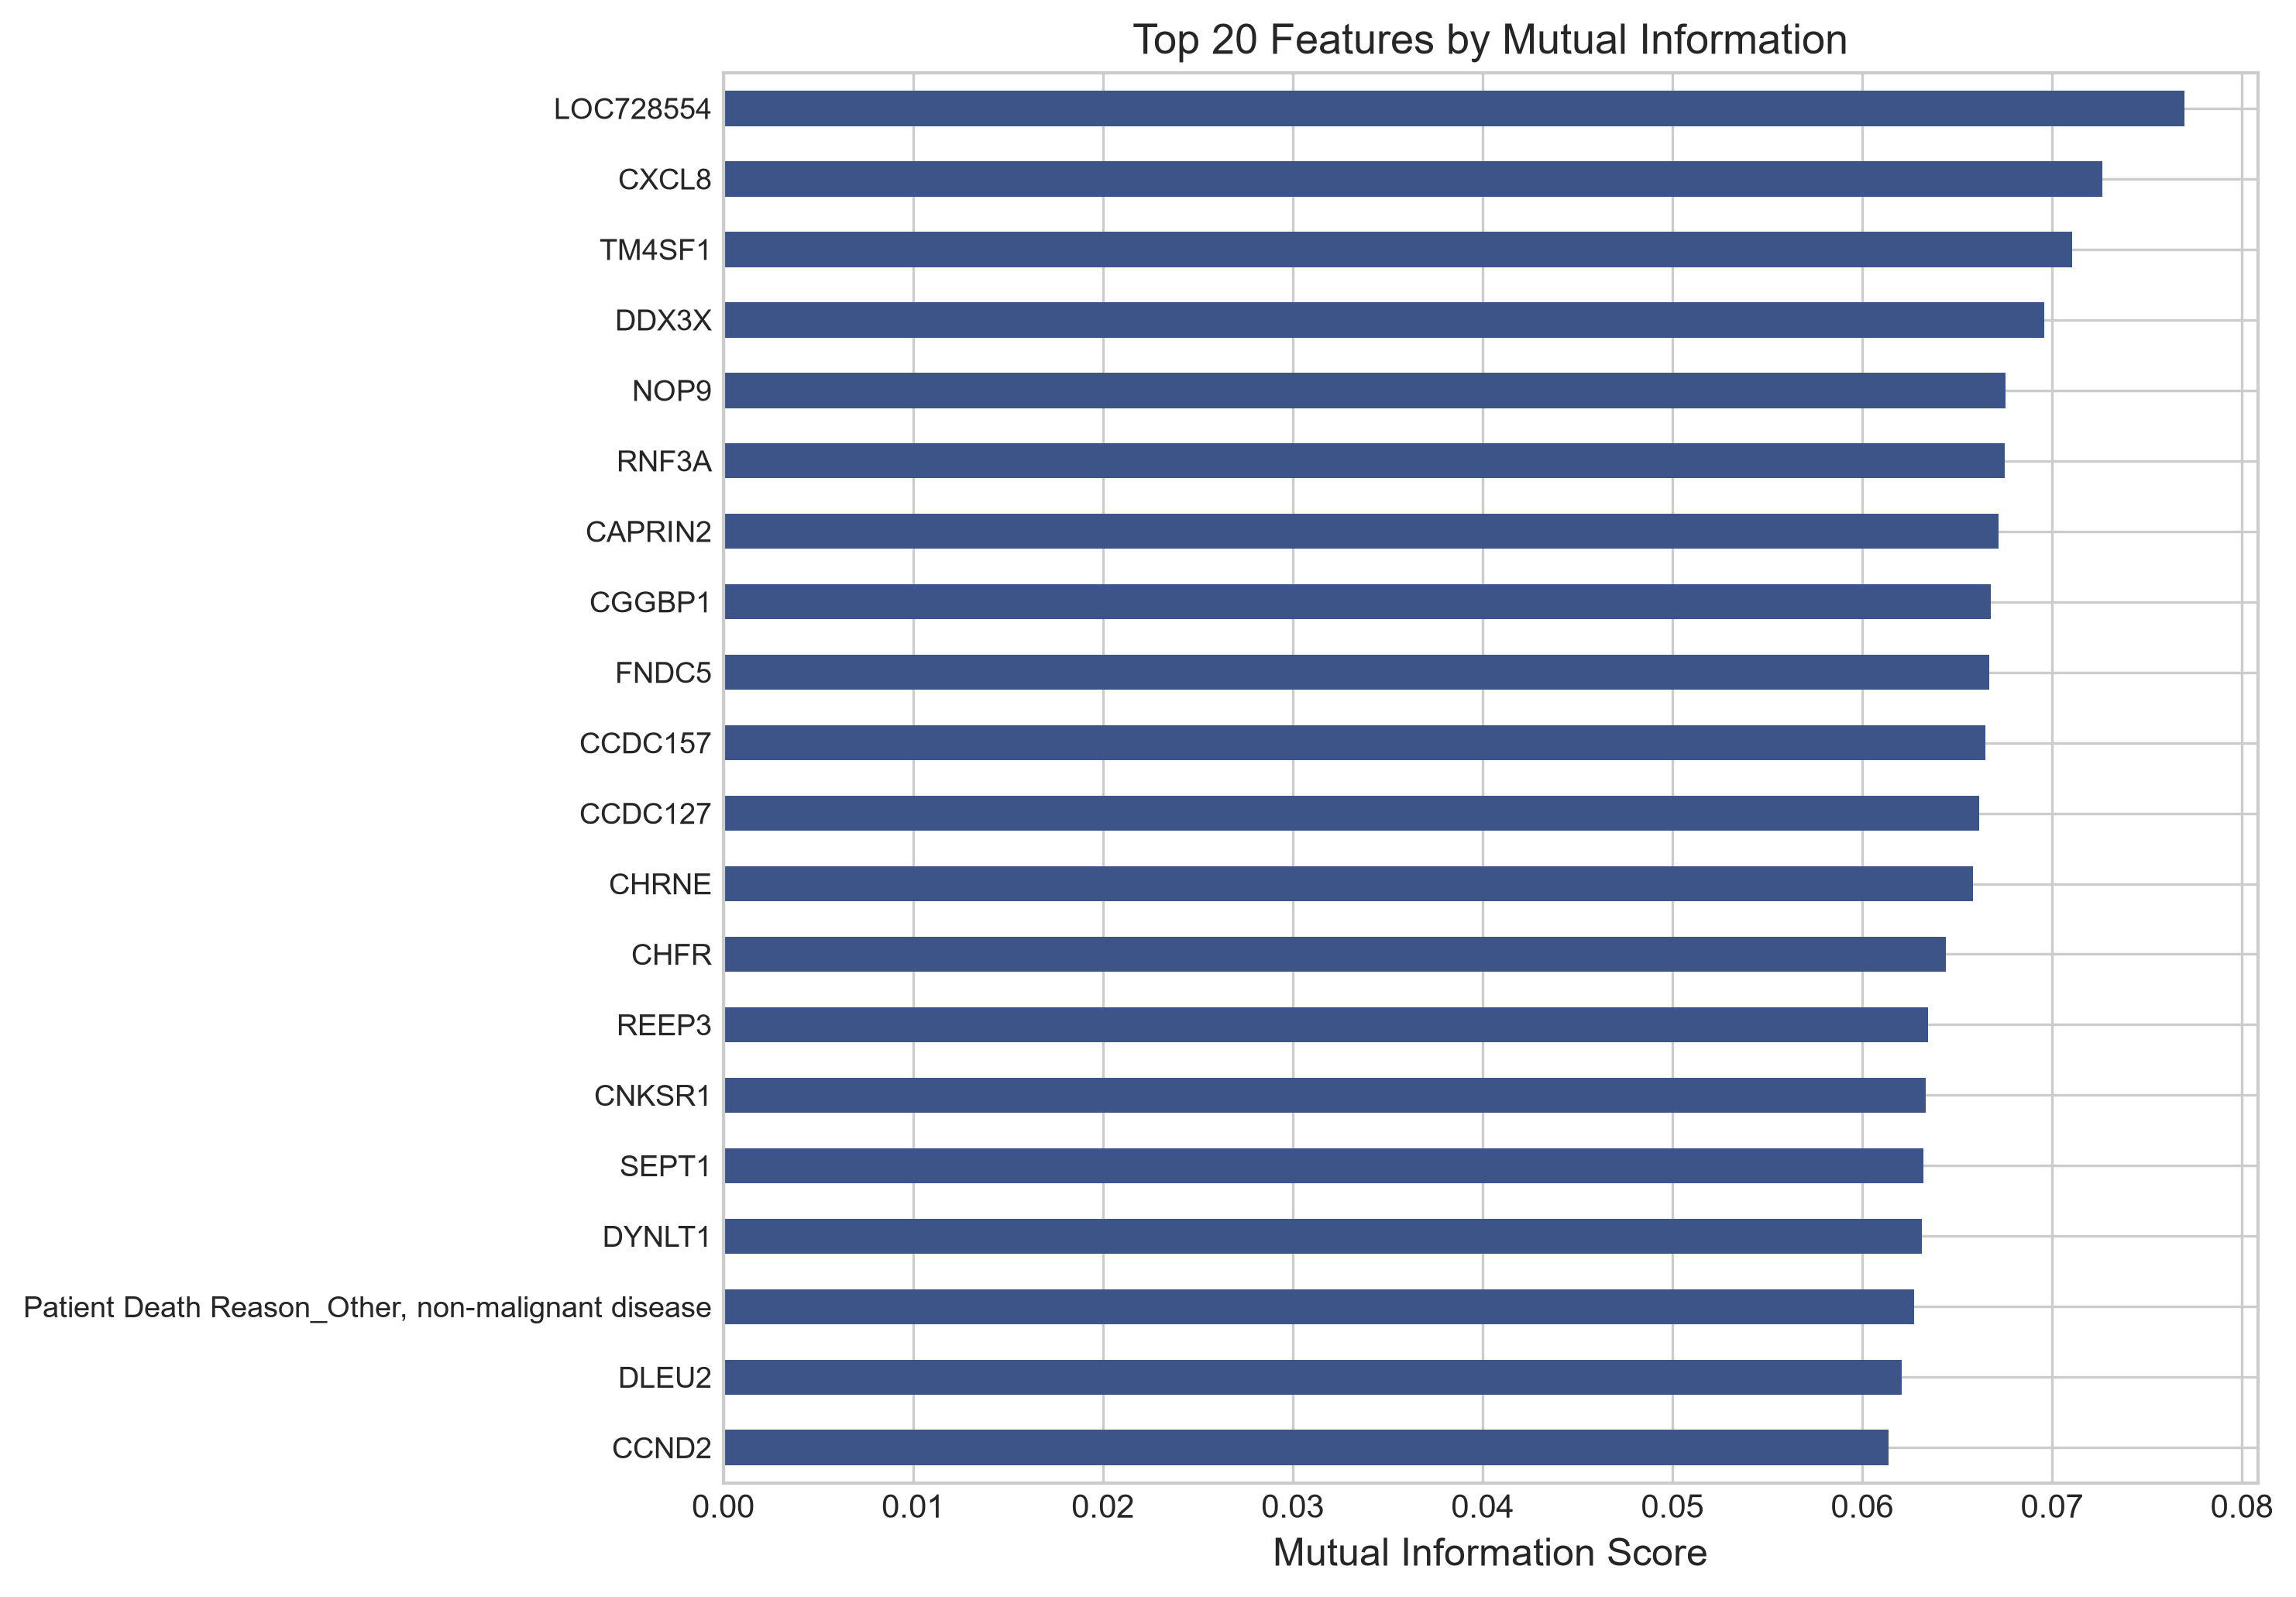

In [5]:
mi_scores = fitted_selector["mi_scores"]
top_mi = mi_scores.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_mi.sort_values().plot(kind="barh", ax=ax, color="#3C5488")
ax.set_xlabel("Mutual Information Score")
ax.set_title("Top 20 Features by Mutual Information")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()

from src.io import save_figure
save_figure(fig, "feature_selection_mi_scores.png")
plt.show()

## Step 5: Transform Test Data Using Fitted Selector

> **Leakage Prevention:** Test data is transformed using selectors
> that were fitted ONLY on training data.

In [6]:
X_train_selected = transform_selected(X_train, fitted_selector, final_features)
X_test_selected = transform_selected(X_test, fitted_selector, final_features)

print(f"Train selected shape: {X_train_selected.shape}")
print(f"Test selected shape:  {X_test_selected.shape}")

Train selected shape: (343, 30)
Test selected shape:  (86, 30)


## Step 6: Save Selected Features and Transformed Data

In [7]:
# Save feature list
save_table(selected_df, "selected_features.csv", index=False)

# Save transformed data
save_dataframe(X_train_selected, "X_train_selected.csv", index=False)
save_dataframe(X_test_selected, "X_test_selected.csv", index=False)

print("Saved:")
print(f"  - selected_features.csv ({len(final_features)} features)")
print(f"  - X_train_selected.csv ({X_train_selected.shape})")
print(f"  - X_test_selected.csv ({X_test_selected.shape})")

2026-08-25 23:04:51 | INFO     | prostate_bcr | Saved 30 rows → D:\Prostate_BCR\core\outputs\tables\selected_features.csv
2026-08-25 23:04:51 | INFO     | prostate_bcr | Saved 343 rows → D:\Prostate_BCR\core\data\processed\X_train_selected.csv
2026-08-25 23:04:51 | INFO     | prostate_bcr | Saved 86 rows → D:\Prostate_BCR\core\data\processed\X_test_selected.csv


Saved:
  - selected_features.csv (30 features)
  - X_train_selected.csv ((343, 30))
  - X_test_selected.csv ((86, 30))
